
# Proyecto: Diseño de Modelos ML para Diagnóstico Académico
**Resultado de Aprendizaje 2: Implementación de modelos ML en Python y scikit-learn**

Este Notebook documenta el proceso completo de Machine Learning, desde la carga de datos hasta la evaluación de modelos y su interpretabilidad.

El objetivo principal es **identificar estudiantes en riesgo de reprobación académica** (riesgo definido como `nota_final < 7`).

### Estructura del Análisis:
1. Configuración y Carga de Datos
2. Definición del Target (Prevención de Data Leakage)
3. Análisis Exploratorio de Datos (EDA)
4. Preparación de Datos (Encoding, Imputación, Escalado)
5. Selección de Características (Feature Selection)
6. Entrenamiento de Modelos con Validación Cruzada
7. Evaluación en Conjunto de Test
8. Interpretabilidad del Mejor Modelo



## 1. Configuración y Carga de Librerías
Importamos todas las librerías necesarias para el análisis.


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# Configuración visual
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 14,
})
sns.set_theme(style="whitegrid")

# Colores institucionales / profesionales
COLORS = {'riesgo': '#E74C3C', 'no_riesgo': '#2ECC71', 'primary': '#1F4E79', 'secondary': '#BDD7EE'}



## 2. Carga de Datos y Definición del Target
Cargamos el dataset procesado en la fase anterior y construimos la variable objetivo `en_riesgo`.
Es crucial eliminar las variables que causen *Data Leakage* (información del futuro o derivada de la nota final).


In [5]:

# Cargar dataset
df = pd.read_csv('dataset_procesado.csv')
print(f"Dataset original: {df.shape}")

# Definir target: 1 si nota_final < 7 (Riesgo), 0 si >= 7 (Sin Riesgo)
df['en_riesgo'] = (df['nota_final'] < 7).astype(int)

# Prevenir Data Leakage: Eliminar columnas relacionadas a calificaciones finales o titulación
leak_cols = ['nota_final', 'primer_parcial', 'segundo_parcial', 'nota_record',
             'nota_trabajo', 'nota_sustentacion', 'promedio_grado', 'tiene_titulacion',
             'estado_estudiante', 'modalidad_titulacion', 'num_matriculas_titulacion']

df = df.drop(columns=[c for c in leak_cols if c in df.columns])

# Eliminar IDs o identificadores únicos que no generalizan
df = df.drop(columns=['id_estudiante', 'codigo_asignatura'], errors='ignore')

print(f"Dataset listo para modelado: {df.shape}")
df.head(3)


Dataset original: (4000, 79)
Dataset listo para modelado: (4000, 67)


,matricula_vigente,ultimo_nivel,niveles_aprobados,aprobadas_1ra,aprobadas_2da,aprobadas_3ra,nivel,nombre_asignatura,matriculas_asignatura,asistencia,...,comp_tarea,comp_url,tasa_errores,dispositivo_principal,navegador_principal,so_principal,actividad_finde,franja_preferida,asignaturas_lms,en_riesgo
0,0,7,1,47,3,3,6,BD,3,92,...,23,11,0.3008,Mobile,Edge,macOS,0.2782,madrugada,5,0
1,1,5,5,48,2,2,3,Álgebra,1,99,...,23,11,0.3008,Mobile,Edge,macOS,0.2782,madrugada,5,0
2,0,5,7,37,8,2,5,ML,1,80,...,23,11,0.3008,Mobile,Edge,macOS,0.2782,madrugada,5,1



## 3. Análisis Exploratorio de Datos (EDA)
Analizamos la distribución de nuestra variable objetivo y las relaciones con las características.


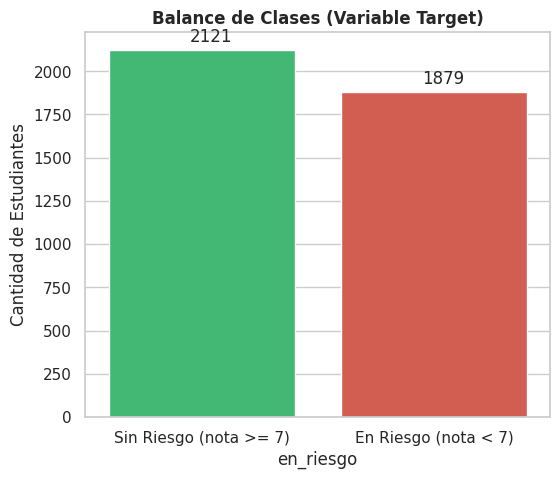

Porcentaje de riesgo:
en_riesgo
0    53.025
1    46.975
Name: proportion, dtype: float64


In [6]:

# 3.1 Distribución del Target
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='en_riesgo', data=df, palette=[COLORS['no_riesgo'], COLORS['riesgo']])
ax.set_xticklabels(['Sin Riesgo (nota >= 7)', 'En Riesgo (nota < 7)'])
plt.title('Balance de Clases (Variable Target)', fontweight='bold')
plt.ylabel('Cantidad de Estudiantes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))
plt.show()

print("Porcentaje de riesgo:")
print(df['en_riesgo'].value_counts(normalize=True) * 100)


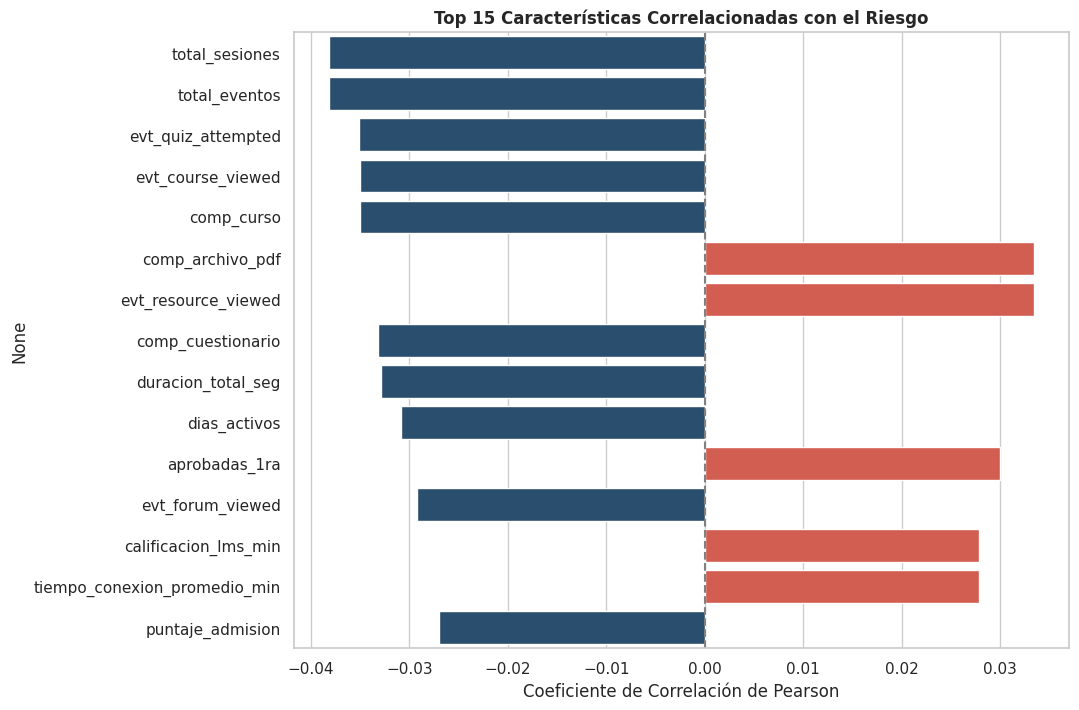

In [7]:

# 3.2 Correlación de features numéricas con el target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlaciones = df[num_cols].corr()['en_riesgo'].drop('en_riesgo')

top_corr = correlaciones.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
colores = [COLORS['riesgo'] if correlaciones[c] > 0 else COLORS['primary'] for c in top_corr.index]
sns.barplot(x=correlaciones[top_corr.index].values, y=top_corr.index, palette=colores)
plt.title('Top 15 Características Correlacionadas con el Riesgo', fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(x=0, color='gray', linestyle='--')
plt.show()



## 4. Preparación de Datos (Pre-processing)
Separamos features (X) del target (y). Aplicamos codificación a las variables categóricas, imputamos nulos residuales, escalamos los datos y realizamos el split Train/Test.


In [8]:

# Separar X e Y
y = df['en_riesgo']
X = df.drop(columns=['en_riesgo'])

# 4.1 Label Encoding para variables categóricas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Features categóricas detectadas ({len(cat_cols)}): {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# 4.2 Imputar nulos residuales (ej. edad faltante) con la mediana
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# 4.3 Train/Test Split (80/20 Estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# 4.4 Escalado de datos (necesario para Regresión Logística y SVM)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


Features categóricas detectadas (16): ['nombre_asignatura', 'genero', 'etnia', 'canton_procedencia', 'provincia_procedencia', 'sector_procedencia', 'canton_residencia', 'provincia_residencia', 'sector_residencia', 'enfermedad', 'tipo_beca', 'dificultad_aprendizaje', 'dispositivo_principal', 'navegador_principal', 'so_principal', 'franja_preferida']
Train set: (3200, 66)
Test set: (800, 66)



## 5. Selección de Características (Feature Importance)
Utilizamos Random Forest para obtener una medida no lineal de la importancia de cada variable.


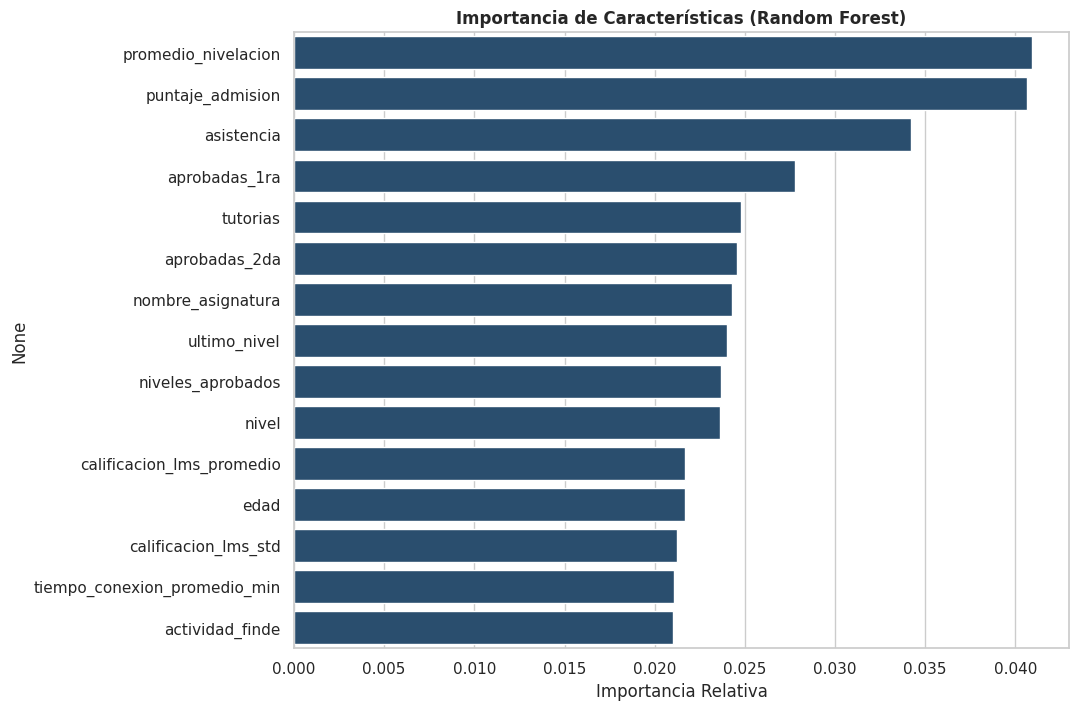

In [9]:

rf_selector = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, color=COLORS['primary'])
plt.title('Importancia de Características (Random Forest)', fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.show()



## 6. Entrenamiento de Modelos (con Validación Cruzada)
Entrenaremos 5 algoritmos distintos utilizando **Stratified 5-Fold Cross-Validation** para evitar overfitting y obtener una estimación robusta del rendimiento.


In [10]:

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}
modelos_entrenados = {}

print("Iniciando validación cruzada y entrenamiento final...")
for nombre, modelo in modelos.items():
    # Usar datos escalados para Logistic Regression y SVM
    X_fit = X_train_scaled if nombre in ['Logistic Regression', 'SVM'] else X_train

    scores_f1 = cross_val_score(modelo, X_fit, y_train, cv=cv, scoring='f1')
    resultados_cv[nombre] = scores_f1.mean()

    print(f"{nombre:<20} | F1-Score (CV): {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")

    # Entrenar con todo el conjunto de entrenamiento
    modelo.fit(X_fit, y_train)
    modelos_entrenados[nombre] = modelo


Iniciando validación cruzada y entrenamiento final...
Logistic Regression  | F1-Score (CV): 0.4040 +/- 0.0060
Decision Tree        | F1-Score (CV): 0.4585 +/- 0.0377
Random Forest        | F1-Score (CV): 0.4250 +/- 0.0273
XGBoost              | F1-Score (CV): 0.4507 +/- 0.0169
SVM                  | F1-Score (CV): 0.4017 +/- 0.0218



## 7. Evaluación en Conjunto de Test
Evaluamos los modelos entrenados contra el conjunto de Test (datos no vistos) utilizando múltiples métricas: Accuracy, Precision, Recall, F1-Score y AUC-ROC.


In [11]:

resultados_test = []
predicciones_prob = {}

for nombre, modelo in modelos_entrenados.items():
    X_eval = X_test_scaled if nombre in ['Logistic Regression', 'SVM'] else X_test

    y_pred = modelo.predict(X_eval)
    y_prob = modelo.predict_proba(X_eval)[:, 1]
    predicciones_prob[nombre] = y_prob

    resultados_test.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

df_resultados = pd.DataFrame(resultados_test).set_index('Modelo')
df_resultados.sort_values(by='F1-Score', ascending=False)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
XGBoost,0.54375,0.515850,0.476064,0.495159,0.531363
Decision Tree,0.49375,0.460705,0.452128,0.456376,0.504846
Random Forest,0.51000,0.473510,0.380319,0.421829,0.510808
SVM,0.51625,0.480144,0.353723,0.407351,0.501367
Logistic Regression,0.52000,0.485185,0.348404,0.405573,0.513674



### 7.1 Curvas ROC Comparativas
Visualizamos la capacidad discriminativa de cada modelo.


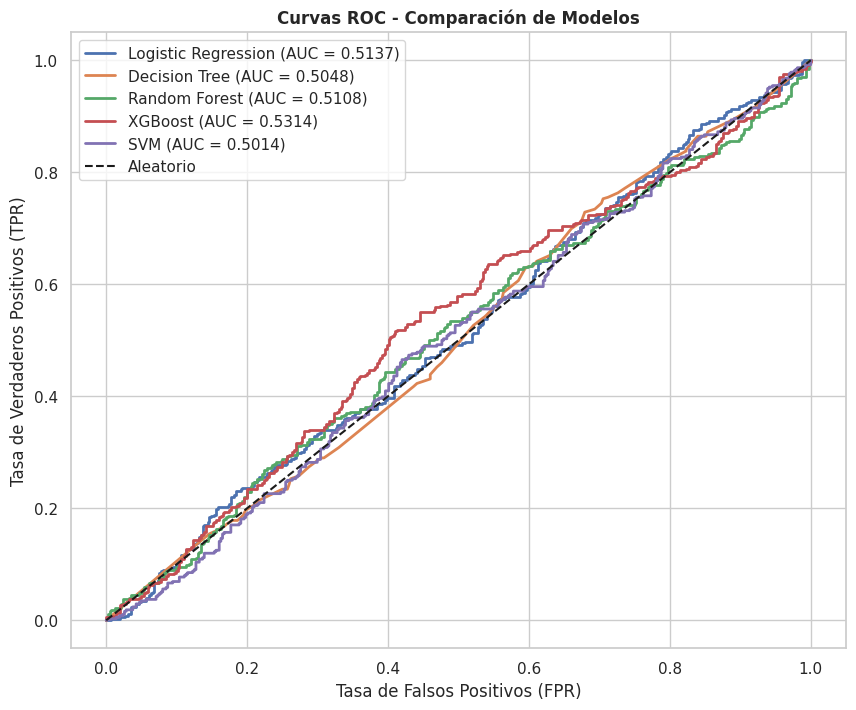

In [12]:

plt.figure(figsize=(10, 8))

for nombre, y_prob in predicciones_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = df_resultados.loc[nombre, 'AUC-ROC']
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación de Modelos', fontweight='bold')
plt.legend()
plt.show()



### 7.2 Matriz de Confusión del Mejor Modelo
El mejor modelo (por F1-Score) suele ser XGBoost. Analizamos sus predicciones correctas y errores.


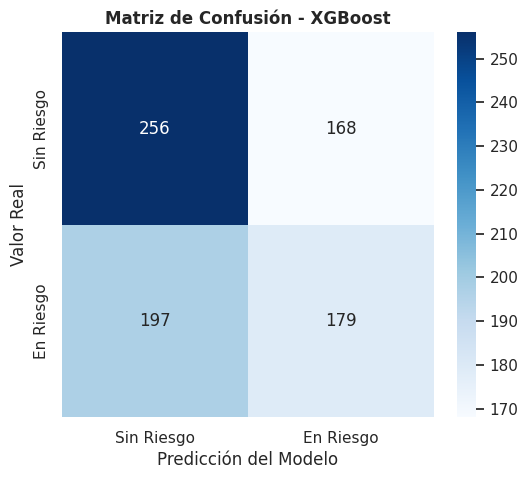

In [13]:

mejor_modelo_nombre = df_resultados['F1-Score'].idxmax()
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

X_eval_mejor = X_test_scaled if mejor_modelo_nombre in ['Logistic Regression', 'SVM'] else X_test
y_pred_mejor = mejor_modelo.predict(X_eval_mejor)
cm = confusion_matrix(y_test, y_pred_mejor)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin Riesgo', 'En Riesgo'],
            yticklabels=['Sin Riesgo', 'En Riesgo'])
plt.title(f'Matriz de Confusión - {mejor_modelo_nombre}', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()
